In [1]:
import torch
import torch.nn as nn
import matplotlib.pylab as plt
from torchvision import datasets,transforms
import torchvision.utils as vutils
from torch.utils.data import dataset,DataLoader

In [2]:
# Global Varaibles:
batch_size=64
latent_dim=100
image_size=28*28 # 28*28=784
epochs=100

In [3]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
# Basic Transformation:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

In [5]:
# Loading the train dataset:
train=datasets.MNIST(root="./train",download=True,train=True,transform=transform)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.94MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]


In [6]:
train

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./train
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [7]:
# Creating the dataloader:
train_dataloader=DataLoader(train,batch_size=batch_size,shuffle=True,drop_last=True)
print(len(train_dataloader))

937


In [8]:
# Generator Network:
class Generator(nn.Module):
  def __init__(self,latent_dim,image_size):
    super().__init__()
    self.network=nn.Sequential(
        nn.Linear(latent_dim,256),
        nn.LeakyReLU(0.2),

        nn.Linear(256,512),
        nn.LeakyReLU(0.2),

        nn.Linear(512,1024),
        nn.LeakyReLU(0.2),

        nn.Linear(1024,image_size),
        nn.Tanh()
    )

  def forward(self,x):
    out=self.network(x)
    return out

In [9]:
# Discriminator Network:
class Discriminator(nn.Module):
  def __init__(self,image_size):
    super().__init__()
    self.network=nn.Sequential(
        nn.Linear(image_size,1024),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),

        nn.Linear(1024,512),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),

        nn.Linear(512,256),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),

        nn.Linear(256,1)
    )

  def forward(self,x):
    out=self.network(x)
    return out.squeeze(1)

In [10]:
# Instances of Generator and Discriminator:
generator=Generator(latent_dim,image_size).to(device)
discriminator=Discriminator(image_size).to(device)

In [11]:
# Loss function and optimizer:
loss=nn.BCEWithLogitsLoss()
goptimizer=torch.optim.Adam(generator.parameters(),lr=1e-4,betas=(0.5,0.999))
doptimizer=torch.optim.Adam(discriminator.parameters(),lr=1e-4,betas=(0.5,0.999))

In [12]:
fixed_noise = torch.randn(64, latent_dim, device=device)

In [13]:
def show_generated_images(generator, noise, epoch):
    generator.eval()

    with torch.no_grad():
        fake_images = generator(noise)

    fake_images = fake_images.view(-1, 1, 28, 28)

    fake_images = (fake_images + 1) / 2

    grid = vutils.make_grid(fake_images, nrow=8)

    plt.figure(figsize=(6,6))
    plt.title(f"Epoch {epoch+1}")
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis("off")
    plt.show()

    generator.train()

Epoch [1/100] | D Loss: 0.7491 | G Loss: 2.6031


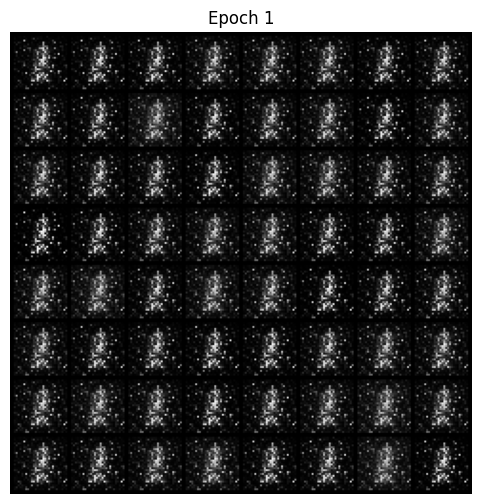

Epoch [11/100] | D Loss: 0.8810 | G Loss: 1.9472


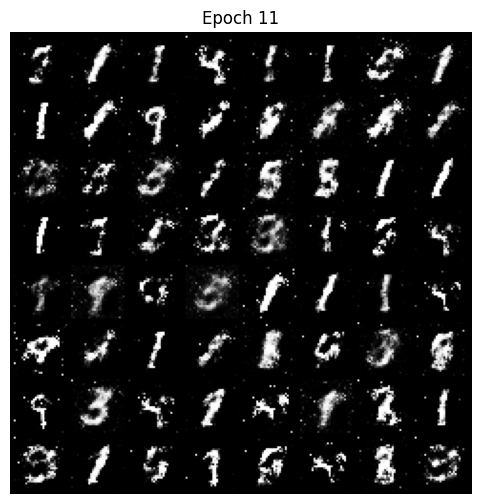

Epoch [21/100] | D Loss: 0.9778 | G Loss: 1.5859


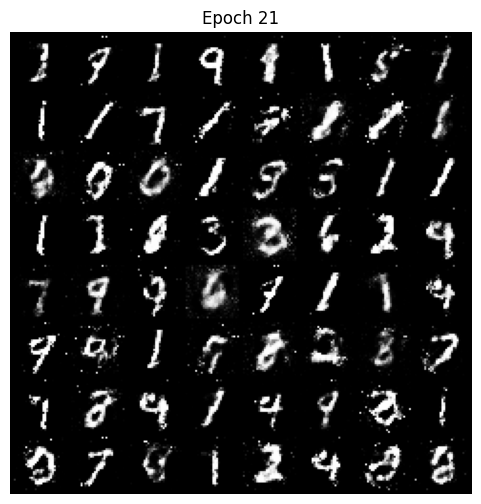

Epoch [31/100] | D Loss: 1.0179 | G Loss: 1.4676


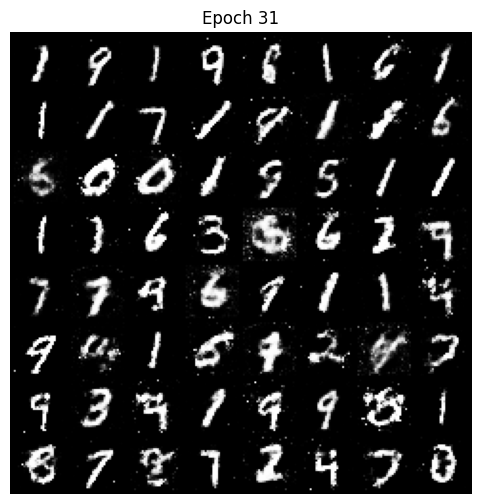

Epoch [41/100] | D Loss: 1.0301 | G Loss: 1.4221


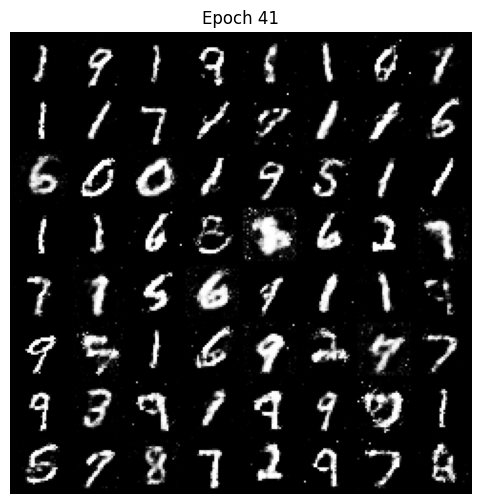

Epoch [51/100] | D Loss: 1.0402 | G Loss: 1.3957


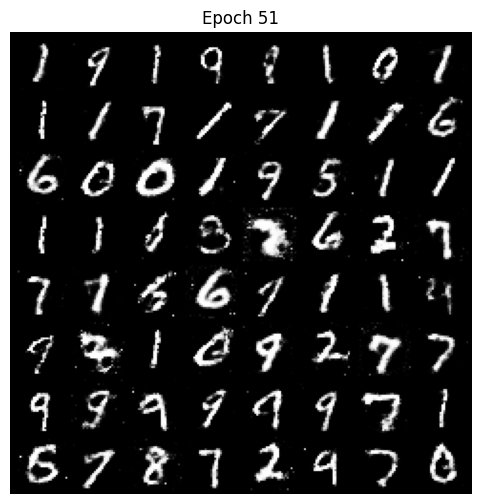

Epoch [61/100] | D Loss: 1.0654 | G Loss: 1.3398


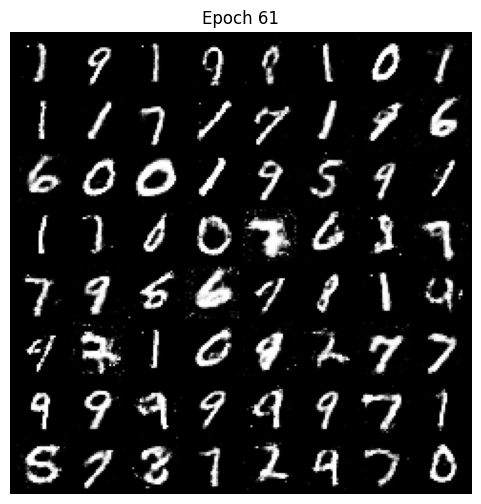

Epoch [71/100] | D Loss: 1.0813 | G Loss: 1.3069


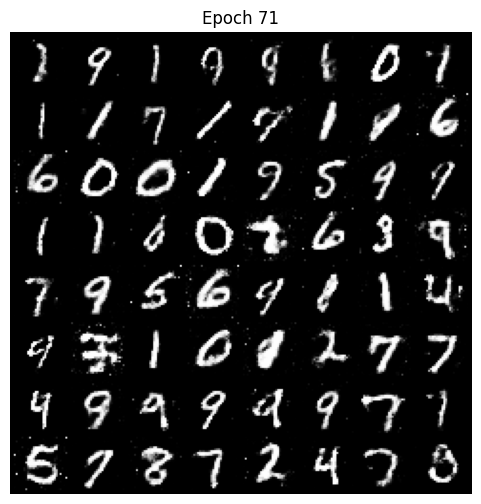

Epoch [81/100] | D Loss: 1.1015 | G Loss: 1.2686


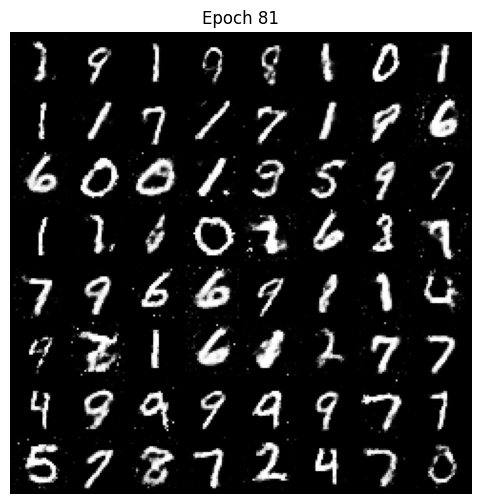

Epoch [91/100] | D Loss: 1.1170 | G Loss: 1.2407


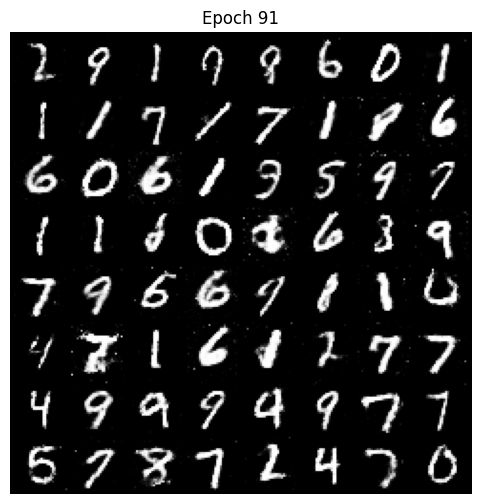

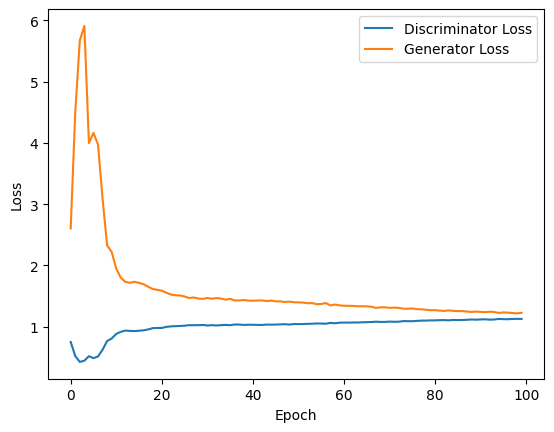

In [15]:
g_losses = []
d_losses = []

for epoch in range(epochs):
  epoch_g_loss = 0
  epoch_d_loss = 0
  num_batches = 0

  for batch_feature,_ in train_dataloader:
    real_images=batch_feature.view(batch_feature.size(0),-1).to(device)
    current_batch_size = real_images.size(0)

    real_labels=torch.ones(current_batch_size,device=device)*0.9
    fake_labels=torch.zeros(current_batch_size,device=device)

    # Train Discriminator:
    doptimizer.zero_grad()
    z=torch.randn(current_batch_size,latent_dim,device=device)
    fake_images=generator(z).detach()

    real_output=discriminator(real_images)
    fake_output=discriminator(fake_images)

    dloss_real=loss(real_output,real_labels)
    dloss_fake=loss(fake_output,fake_labels)

    dloss=dloss_real+dloss_fake
    dloss.backward()
    doptimizer.step()

    # Generator Training:
    goptimizer.zero_grad()

    z=torch.randn(current_batch_size,latent_dim,device=device)
    fake_images=generator(z)

    output=discriminator(fake_images)
    gloss=loss(output,real_labels)

    gloss.backward()
    goptimizer.step()

    epoch_d_loss += dloss.item()
    epoch_g_loss += gloss.item()
    num_batches += 1

  avg_d_loss = epoch_d_loss / num_batches
  avg_g_loss = epoch_g_loss / num_batches

  d_losses.append(avg_d_loss)
  g_losses.append(avg_g_loss)

  if epoch%10==0:
    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f}")
    show_generated_images(generator,fixed_noise,epoch)

plt.plot(d_losses, label="Discriminator Loss")
plt.plot(g_losses, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
